# Global 모델링 Stage 4 — 고정 Test 최종 비교

> **경고:** 이 Notebook을 실행하면 고정 Global Test Dataset에 대한 최종 평가가 수행됩니다. Test 결과 확인 이후 Feature, Hyperparameter, Threshold를 변경하지 않습니다.

네 고정 후보(LR/XGB × 1차 42개 Feature/2차 25개 Feature)를 threshold=0.5로 평가한다. 결과를 자동 해석하거나 최종 모델을 선택하지 않는다.

In [10]:
import importlib, json, os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

ROOT = Path(os.environ.get('KHUDA_PROJECT_ROOT', Path.cwd())).resolve()
while not (ROOT / 'code').is_dir():
    if ROOT.parent == ROOT: raise RuntimeError('KHUDA_PROJECT_ROOT에 저장소 루트를 지정하거나 저장소 안에서 실행하세요.')
    ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
if 'code' in sys.modules and not hasattr(sys.modules['code'], '__path__'): del sys.modules['code']
for module in ('code.model.final_evaluation', 'code.evaluation.bootstrap', 'code.evaluation.importance'):
    if module in sys.modules: importlib.reload(sys.modules[module])
from code.evaluation.bootstrap import bootstrap_confidence_intervals, paired_bootstrap_f1_difference
from code.evaluation.importance import calculate_feature_importance
from code.model.final_evaluation import (fit_final_candidates, load_final_candidates, load_stage4_cv_f1, predict_final_candidates, save_final_test_artifacts, summarize_final_predictions)
from code.pipeline.saved_results import load_saved_global_train_test
from code.preprocess.build_features import load_feature_config

RESULT_ROOT = ROOT / 'data' / 'result' / 'baseline_42features'
DATASET_PATH = RESULT_ROOT / 'datasets' / 'global_dataset.parquet'
SPLIT_PATH = RESULT_ROOT / 'splits' / 'split_ids.csv'
STAGE_1_DIR = RESULT_ROOT / 'modeling' / 'stage_1'
STAGE_3_DIR = RESULT_ROOT / 'modeling' / 'stage_3'
STAGE_3_5_DIR = RESULT_ROOT / 'modeling' / 'stage_3_5'
OUTPUT_DIR = RESULT_ROOT / 'modeling' / 'stage_4'
FEATURE_CONFIG = ROOT / 'code' / 'config' / 'features.yaml'
MODEL_CONFIG = ROOT / 'code' / 'config' / 'model_config.yaml'
THRESHOLD, BOOTSTRAP_REPEATS, PERMUTATION_REPEATS = 0.5, 1000, 20
LABELS = {'lr_stage_1':'LR 1차', 'lr_stage_2':'LR 2차', 'xgb_stage_1':'XGBoost 1차', 'xgb_stage_2':'XGBoost 2차'}
COLORS = {'lr_stage_1':'#7a7a7a', 'lr_stage_2':'#0066cc', 'xgb_stage_1':'#333333', 'xgb_stage_2':'#2997ff'}
plt.rcParams.update({'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#e0e0e0','text.color':'#1d1d1f'})

In [11]:
# 이 셀부터 Test를 처음 사용한다. 실행 전에는 위 경고와 고정 artifact 경로를 다시 확인하세요.
required = [DATASET_PATH, SPLIT_PATH, STAGE_1_DIR/'best_params.json', STAGE_3_DIR/'selected_features.csv', STAGE_3_5_DIR/'final_refined_params.json', FEATURE_CONFIG, MODEL_CONFIG]
missing = [str(path) for path in required if not path.exists()]
if missing: raise FileNotFoundError('필수 입력이 없습니다:\n' + '\n'.join(missing))
feature_config = load_feature_config(FEATURE_CONFIG)
all_features = [item['name'] for item in feature_config['features']]
candidates = load_final_candidates(stage_1_dir=STAGE_1_DIR, stage_3_5_dir=STAGE_3_5_DIR, selected_features_path=STAGE_3_DIR/'selected_features.csv', all_feature_names=all_features)
train_bundle, test_bundle = load_saved_global_train_test(DATASET_PATH, SPLIT_PATH, FEATURE_CONFIG)
overlap = set(train_bundle.groups.astype('string')) & set(test_bundle.groups.astype('string'))
audit = pd.DataFrame([{'train_rows':len(train_bundle.X), 'train_unique_SAMPID':train_bundle.groups.nunique(), 'test_rows':len(test_bundle.X), 'test_unique_SAMPID':test_bundle.groups.nunique(), 'train_test_SAMPID_overlap':len(overlap), 'stage_1_feature_count':42, 'stage_2_feature_count':25, 'threshold':THRESHOLD, 'bootstrap_repeats':BOOTSTRAP_REPEATS, 'permutation_repeats':PERMUTATION_REPEATS}])
display(audit)
display(pd.DataFrame([{'candidate':c.key, 'model':c.model, 'stage':c.stage, 'n_features':len(c.feature_names), 'best_params':c.params} for c in candidates]))
if overlap: raise RuntimeError('고정 Global split에 Train/Test SAMPID overlap이 있습니다.')

,train_rows,train_unique_SAMPID,test_rows,test_unique_SAMPID,train_test_SAMPID_overlap,stage_1_feature_count,stage_2_feature_count,threshold,bootstrap_repeats,permutation_repeats
0,11925,5737,2981,1406,0,42,25,0.5,1000,20


,candidate,model,stage,n_features,best_params
0,lr_stage_1,logistic_regression,stage_1,42,"{'C': 1, 'class_weight': 'balanced', 'penalty'..."
1,lr_stage_2,logistic_regression,stage_2,25,"{'C': 0.3, 'class_weight': 'balanced', 'penalt..."
2,xgb_stage_1,xgboost,stage_1,42,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
3,xgb_stage_2,xgboost,stage_2,25,"{'subsample': 1.0, 'colsample_bytree': 0.8, 's..."


In [12]:
# Train 전체에서만 전처리 fit 및 고정 파라미터 학습.
fitted_models = fit_final_candidates(train_bundle, candidates, feature_config=FEATURE_CONFIG, model_config=MODEL_CONFIG)

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ra

In [13]:
# 고정 Test 확률 예측과 threshold=0.5 분류.
test_predictions = predict_final_candidates(test_bundle, candidates, fitted_models, threshold=THRESHOLD)

In [14]:
# Test metric과 CV-vs-Test 비교.
test_summary, confusion_matrices = summarize_final_predictions(test_predictions, candidates, threshold=THRESHOLD)
cv_f1 = load_stage4_cv_f1(STAGE_1_DIR, STAGE_3_5_DIR)
final_comparison = test_summary.merge(cv_f1, on=['model','stage'], how='left').rename(columns={'cv_f1_mean':'cv_f1'})
final_comparison['test_f1_minus_cv_f1'] = final_comparison['test_f1'] - final_comparison['cv_f1']
display(final_comparison)

,candidate,model,stage,feature_count,test_rows,test_unique_SAMPID,positive_count,negative_count,positive_rate,predicted_positive_count,predicted_positive_rate,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_average_precision,best_params,cv_f1,test_f1_minus_cv_f1
0,lr_stage_1,logistic_regression,stage_1,42,2981,1406,780,2201,0.261657,1057,0.354579,0.692385,0.435194,0.589744,0.500817,0.709497,0.425213,"{'C': 1, 'class_weight': 'balanced', 'penalty'...",0.491064,0.009753
1,lr_stage_2,logistic_regression,stage_2,25,2981,1406,780,2201,0.261657,1061,0.355921,0.686347,0.426956,0.580769,0.492124,0.710591,0.420900,"{'C': 0.3, 'class_weight': 'balanced', 'penalt...",0.493122,-0.000998
2,xgb_stage_1,xgboost,stage_1,42,2981,1406,780,2201,0.261657,1202,0.403220,0.675277,0.421797,0.650000,0.511604,0.721827,0.447238,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.505448,0.006156
3,xgb_stage_2,xgboost,stage_2,25,2981,1406,780,2201,0.261657,1228,0.411942,0.673264,0.421010,0.662821,0.514940,0.721705,0.440620,"{'subsample': 1.0, 'colsample_bytree': 0.8, 's...",0.507894,0.007046


In [15]:
# SAMPID 단위 bootstrap 1,000회. 같은 사람의 Person-Period는 함께 복원추출된다.
bootstrap_ci = pd.concat([bootstrap_confidence_intervals(frame.y_true, frame.y_proba, frame.SAMPID, threshold=THRESHOLD, n_repeats=BOOTSTRAP_REPEATS, random_state=42).query("metric == 'f1'").assign(candidate=key) for key, frame in test_predictions.items()], ignore_index=True)
pairs = [('lr_stage_2','lr_stage_1'), ('xgb_stage_2','xgb_stage_1'), ('xgb_stage_2','lr_stage_2')]
pairwise_bootstrap = pd.concat([paired_bootstrap_f1_difference(test_predictions[a].y_true, test_predictions[a].y_proba, test_predictions[b].y_proba, test_predictions[a].SAMPID, threshold=THRESHOLD, n_repeats=BOOTSTRAP_REPEATS, random_state=42, comparison=f'{a} - {b}') for a, b in pairs], ignore_index=True)
display(bootstrap_ci); display(pairwise_bootstrap)

,metric,estimate,bootstrap_mean,ci95_lower,ci95_upper,n_valid_repeats,n_repeats,bootstrap_unit,threshold,candidate
0,f1,0.500817,0.501263,0.471797,0.531411,1000,1000,SAMPID,0.5,lr_stage_1
1,f1,0.492124,0.492415,0.463791,0.522389,1000,1000,SAMPID,0.5,lr_stage_2
2,f1,0.511604,0.511628,0.483962,0.539059,1000,1000,SAMPID,0.5,xgb_stage_1
3,f1,0.514940,0.515235,0.489389,0.542048,1000,1000,SAMPID,0.5,xgb_stage_2


,comparison,point_estimate_delta_f1,bootstrap_mean_delta,ci95_lower,ci95_upper,n_repeats,bootstrap_unit,threshold
0,lr_stage_2 - lr_stage_1,-0.008693,-0.008848,-0.017549,-0.000807,1000,SAMPID,0.5
1,xgb_stage_2 - xgb_stage_1,0.003336,0.003607,-0.004259,0.012681,1000,SAMPID,0.5
2,xgb_stage_2 - lr_stage_2,0.022816,0.022820,0.005633,0.039307,1000,SAMPID,0.5


In [16]:
# 2차 25개 Feature held-out Test PI. 재선택에 사용하지 않는 최종 진단 자료다.
candidate_by_key = {candidate.key:candidate for candidate in candidates}
permutation_importance = {}
for key in ('lr_stage_2','xgb_stage_2'):
    candidate = candidate_by_key[key]
    X_test = test_bundle.X.loc[:, list(candidate.feature_names)]
    permutation_importance[key] = calculate_feature_importance(fitted_models[key], X_test, test_bundle.y, scoring='f1', n_repeats=PERMUTATION_REPEATS, random_state=42)
display(permutation_importance['lr_stage_2']); display(permutation_importance['xgb_stage_2'])

,feature,importance_mean,importance_std,positive_repeat_count,scoring,n_repeats,rank
0,student_status,0.047748,0.008321,20,f1,20,1
1,recent_job_search,0.010432,0.003170,20,f1,20,2
2,months_since_graduation,0.010143,0.003214,20,f1,20,3
3,university_type,0.007435,0.002988,20,f1,20,4
4,age,0.007002,0.004607,19,f1,20,5
5,recent_employment_prep,0.006845,0.003644,18,f1,20,6
6,ever_worked_before,0.004702,0.002474,18,f1,20,7
7,region_5,0.004464,0.003032,17,f1,20,8
8,major_group,0.003116,0.003157,17,f1,20,9
9,has_employment_certificate,0.002788,0.002459,19,f1,20,10


,feature,importance_mean,importance_std,positive_repeat_count,scoring,n_repeats,rank
0,student_status,0.035664,0.006646,20,f1,20,1
1,months_since_graduation,0.024470,0.004638,20,f1,20,2
2,age,0.021201,0.004130,20,f1,20,3
3,major_group,0.014239,0.004981,20,f1,20,4
4,gender,0.010724,0.004002,20,f1,20,5
5,recent_job_search,0.010634,0.003360,20,f1,20,6
6,university_type,0.010478,0.003933,20,f1,20,7
7,ever_worked_before,0.005825,0.001495,20,f1,20,8
8,has_certificate,0.003638,0.002120,18,f1,20,9
9,region_5,0.002657,0.004355,15,f1,20,10


In [17]:
# 사람이 실행했을 때만 Test 결과 artifact를 저장한다.
artifact_paths = save_final_test_artifacts(output_dir=OUTPUT_DIR, summary=final_comparison, bootstrap_ci=bootstrap_ci, pairwise_bootstrap=pairwise_bootstrap, predictions=test_predictions, permutation_importance=permutation_importance, confusion_matrices=confusion_matrices)
display(pd.DataFrame({'artifact':list(artifact_paths), 'path':[str(path) for path in artifact_paths.values()]}))

,artifact,path
0,final_test_summary,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
1,final_test_bootstrap_ci,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
2,final_test_pairwise_bootstrap,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
3,final_test_predictions,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
4,final_model_comparison,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
5,confusion_matrices,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
6,lr_stage_2_permutation_importance,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
7,xgb_stage_2_permutation_importance,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...


/var/folders/ng/n4_gg6g94q56fngdv612lrvm0000gn/T/ipykernel_60288/2380262618.py:6: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  axes[1].set(title='Global Stage 4: Test Metrics', xlabel='Metric', ylabel='Score', ylim=(0,1)); axes[1].set_xticks(x,['Accuracy','Precision','Recall','F1']); axes[1].legend(); plt.tight_layout(); plt.show()
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


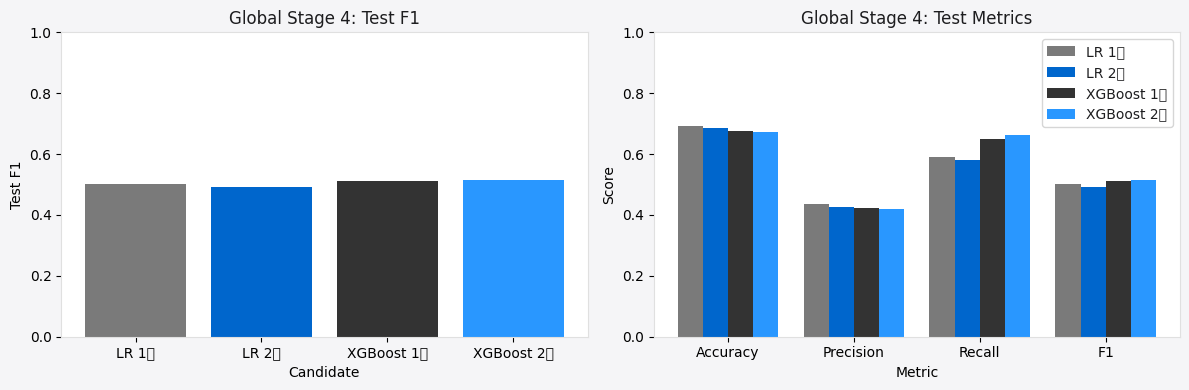

/var/folders/ng/n4_gg6g94q56fngdv612lrvm0000gn/T/ipykernel_60288/2380262618.py:11: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.suptitle('Global Stage 4: Test Confusion Matrices'); plt.tight_layout(); plt.show()
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


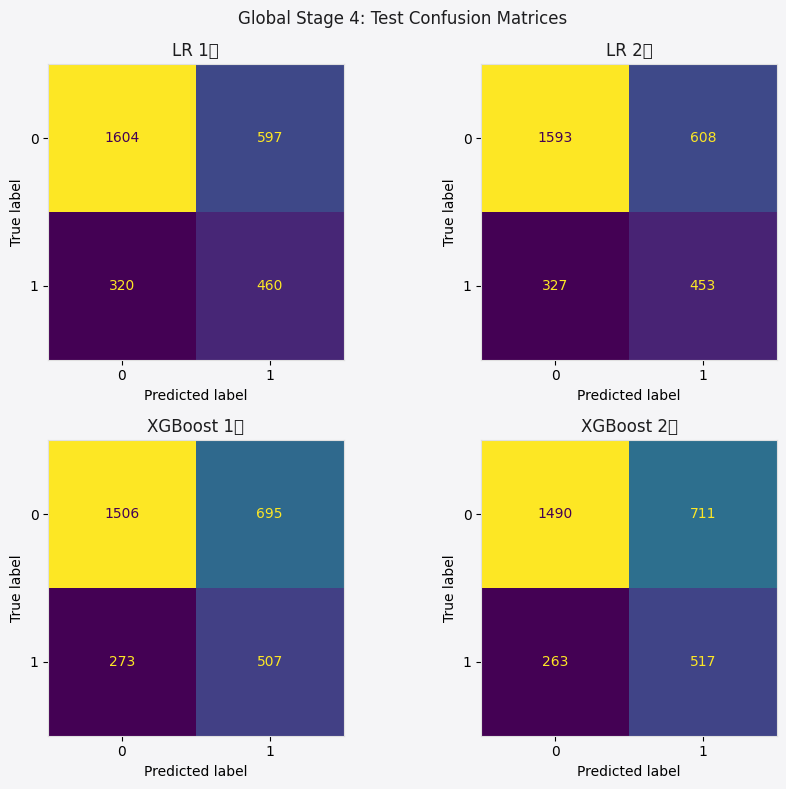

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


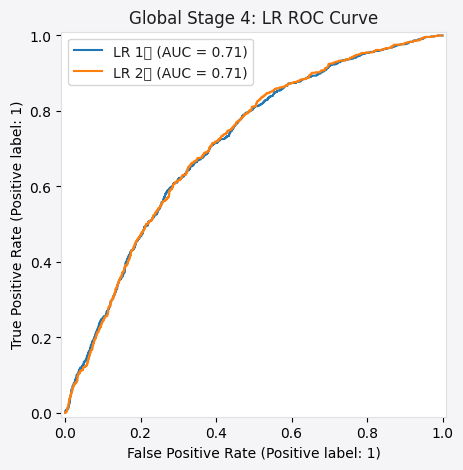

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


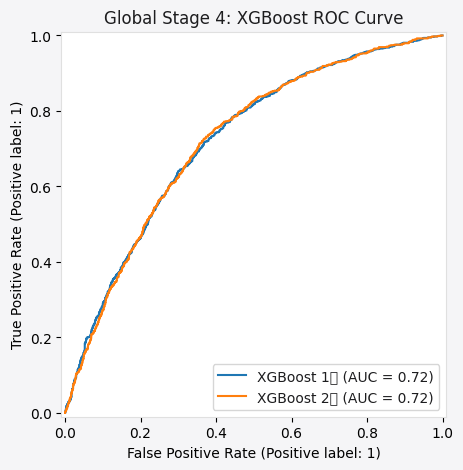

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


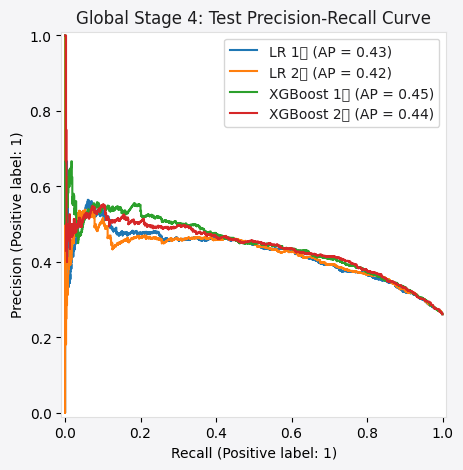

In [18]:
# Test F1 및 Accuracy/Precision/Recall/F1.
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].bar([LABELS[k] for k in final_comparison.candidate], final_comparison.test_f1, color=[COLORS[k] for k in final_comparison.candidate]); axes[0].set(title='Global Stage 4: Test F1', xlabel='Candidate', ylabel='Test F1', ylim=(0,1))
metrics = ['test_accuracy','test_precision','test_recall','test_f1']; x=np.arange(4); width=.2
for i,row in enumerate(final_comparison.itertuples()): axes[1].bar(x+(i-1.5)*width,[getattr(row,m) for m in metrics],width,label=LABELS[row.candidate],color=COLORS[row.candidate])
axes[1].set(title='Global Stage 4: Test Metrics', xlabel='Metric', ylabel='Score', ylim=(0,1)); axes[1].set_xticks(x,['Accuracy','Precision','Recall','F1']); axes[1].legend(); plt.tight_layout(); plt.show()

# 네 confusion matrix, 두 모델군별 ROC, 네 모델 PR curve.
fig, axes = plt.subplots(2,2,figsize=(9,8))
for ax,(key,frame) in zip(axes.ravel(),test_predictions.items()): ConfusionMatrixDisplay.from_predictions(frame.y_true,frame.y_pred,ax=ax,colorbar=False); ax.set_title(LABELS[key])
fig.suptitle('Global Stage 4: Test Confusion Matrices'); plt.tight_layout(); plt.show()
for family,keys in [('LR',('lr_stage_1','lr_stage_2')),('XGBoost',('xgb_stage_1','xgb_stage_2'))]:
    fig,ax=plt.subplots(figsize=(6,5))
    for key in keys: RocCurveDisplay.from_predictions(test_predictions[key].y_true,test_predictions[key].y_proba,name=LABELS[key],ax=ax)
    ax.set_title(f'Global Stage 4: {family} ROC Curve'); ax.legend(); plt.show()
fig,ax=plt.subplots(figsize=(6,5))
for key,frame in test_predictions.items(): PrecisionRecallDisplay.from_predictions(frame.y_true,frame.y_proba,name=LABELS[key],ax=ax)
ax.set_title('Global Stage 4: Test Precision-Recall Curve'); ax.legend(); plt.show()

/var/folders/ng/n4_gg6g94q56fngdv612lrvm0000gn/T/ipykernel_60288/2700246737.py:3: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig,ax=plt.subplots(figsize=(8,4)); values=final_comparison.test_f1.to_numpy(); errors=np.vstack([values-ci.ci95_lower.to_numpy(),ci.ci95_upper.to_numpy()-values]); ax.bar([LABELS[k] for k in final_comparison.candidate],values,yerr=errors,capsize=5,color=[COLORS[k] for k in final_comparison.candidate]); ax.set(title='Global Stage 4: Test F1 with SAMPID Bootstrap 95% CI',xlabel='Candidate',ylabel='Test F1',ylim=(0,1)); plt.tight_layout(); plt.show()
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


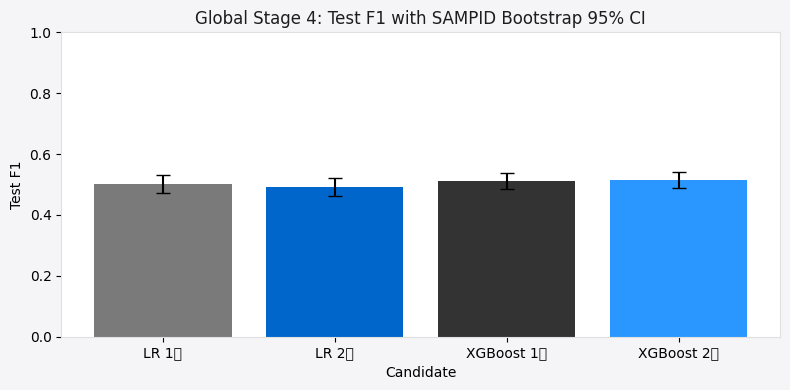

,comparison,point_estimate_delta_f1,bootstrap_mean_delta,ci95_lower,ci95_upper,n_repeats,bootstrap_unit,threshold
0,lr_stage_2 - lr_stage_1,-0.008693,-0.008848,-0.017549,-0.000807,1000,SAMPID,0.5
1,xgb_stage_2 - xgb_stage_1,0.003336,0.003607,-0.004259,0.012681,1000,SAMPID,0.5


/var/folders/ng/n4_gg6g94q56fngdv612lrvm0000gn/T/ipykernel_60288/2700246737.py:6: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  frame=permutation_importance[key].sort_values('importance_mean'); fig,ax=plt.subplots(figsize=(7,7)); ax.barh(frame.feature,frame.importance_mean,xerr=frame.importance_std,color=COLORS[key]); ax.set(title=f'{LABELS[key]}: Held-out Test Permutation Importance',xlabel='F1 importance',ylabel='Original feature'); plt.tight_layout(); plt.show()
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


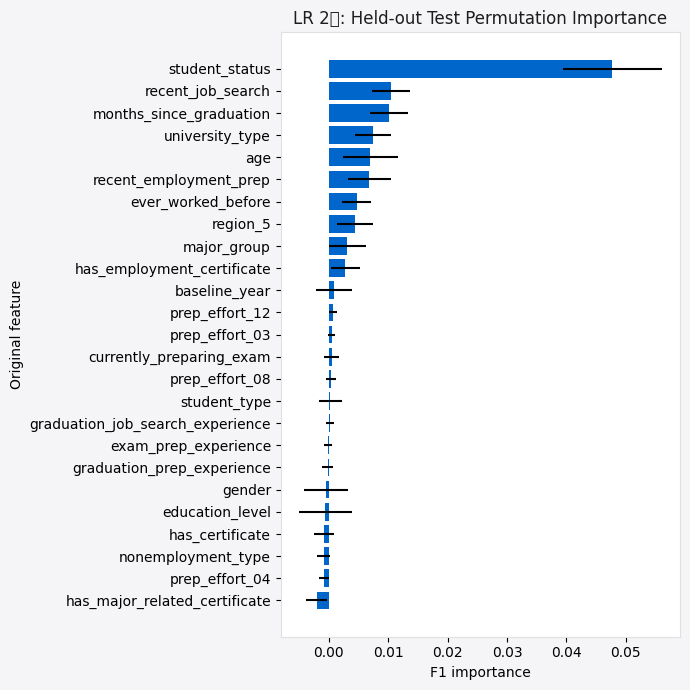

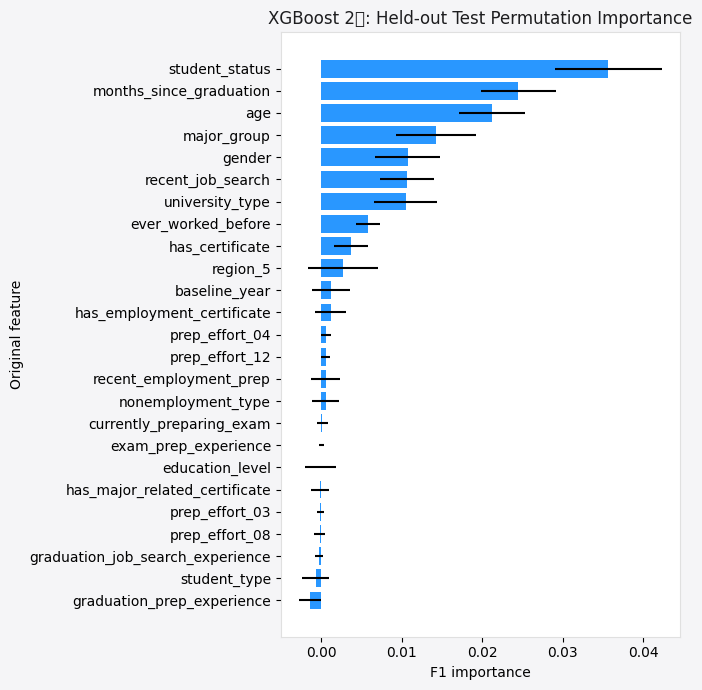

,model,stage,feature_count,cv_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_average_precision,ci95_lower,ci95_upper
0,logistic_regression,stage_1,42,0.491064,0.692385,0.435194,0.589744,0.500817,0.709497,0.425213,0.471797,0.531411
1,logistic_regression,stage_2,25,0.493122,0.686347,0.426956,0.580769,0.492124,0.710591,0.420900,0.463791,0.522389
2,xgboost,stage_1,42,0.505448,0.675277,0.421797,0.650000,0.511604,0.721827,0.447238,0.483962,0.539059
3,xgboost,stage_2,25,0.507894,0.673264,0.421010,0.662821,0.514940,0.721705,0.440620,0.489389,0.542048


In [19]:
# Bootstrap CI, Feature selection 전후 ΔF1, 2차 PI.
ci = bootstrap_ci.set_index('candidate').loc[final_comparison.candidate]
fig,ax=plt.subplots(figsize=(8,4)); values=final_comparison.test_f1.to_numpy(); errors=np.vstack([values-ci.ci95_lower.to_numpy(),ci.ci95_upper.to_numpy()-values]); ax.bar([LABELS[k] for k in final_comparison.candidate],values,yerr=errors,capsize=5,color=[COLORS[k] for k in final_comparison.candidate]); ax.set(title='Global Stage 4: Test F1 with SAMPID Bootstrap 95% CI',xlabel='Candidate',ylabel='Test F1',ylim=(0,1)); plt.tight_layout(); plt.show()
delta = pairwise_bootstrap[pairwise_bootstrap.comparison.isin(['lr_stage_2 - lr_stage_1','xgb_stage_2 - xgb_stage_1'])]; display(delta)
for key in ('lr_stage_2','xgb_stage_2'):
    frame=permutation_importance[key].sort_values('importance_mean'); fig,ax=plt.subplots(figsize=(7,7)); ax.barh(frame.feature,frame.importance_mean,xerr=frame.importance_std,color=COLORS[key]); ax.set(title=f'{LABELS[key]}: Held-out Test Permutation Importance',xlabel='F1 importance',ylabel='Original feature'); plt.tight_layout(); plt.show()

# 발표용 최종 표: 수치만 표시하며 자동 선택·해석을 하지 않는다.
presentation_columns=['model','stage','feature_count','cv_f1','test_accuracy','test_precision','test_recall','test_f1','test_roc_auc','test_average_precision']
presentation = final_comparison.merge(ci[['ci95_lower','ci95_upper']],left_on='candidate',right_index=True,how='left').loc[:,presentation_columns+['ci95_lower','ci95_upper']]
display(presentation)